# SmartStay AI: İçerik Tabanlı Öneri Motoru ve TF-IDF Vektörizasyonu

Bu çalışma, **SmartStay AI** platformunun İçerik Tabanlı Öneri Motoru (Content-Based Recommendation Engine) modülünün metin vektörizasyon altyapısını oluşturmaktadır. İşlenmiş konaklama veri seti (`cleaned_listings.csv`) üzerinde yer alan metin tabanlı özellikler (ilan başlığı, açıklaması, konumu, oda tipi ve olanakları) birleştirilerek doğal dil işleme (NLP) ön işlemelerinden geçirilmiş ve **TF-IDF (Term Frequency - Inverse Document Frequency)** yöntemiyle yüksek boyutlu sayısal vektör uzayına dönüştürülmüştür.

---

### Metodolojik Aşamalar
1. **Veri Setinin Yüklenmesi ve Metin Alanlarının İncelenmesi:**
   * Gün 5 sonunda elde edilen 22.665 satırlık temizlenmiş veri setinin yüklenmesi.
   * `name`, `description`, `neighbourhood_cleansed`, `room_type` ve `amenities` metin kolonlarının dağılım ve doluluk analizleri.

2. **Metin Ön İşleme ve Özellik Birleştirme (`combined_features`):**
   * HTML etiketlerinin, özel karakterlerin ve noktalama işaretlerinin temizlenmesi.
   * Küçük harfe dönüştürme (lowercasing) ve fazla boşlukların giderilmesi.
   * Tüm tanımlayıcı alanların tek bir zengin metin gövdesinde (`combined_features`) birleştirilmesi.

3. **TF-IDF Vektörizasyonu:**
   * N-Gram (Unigram & Bigram: 1, 2) parametreleri ve İngilizce stop-words filtrelemesi.
   * `sublinear_tf=True` ve `max_features=5000` ile optimize edilmiş terim frekansı matrisinin üretilmesi.
   * Vektör uzayı boyutlarının, seyreklik oranının (sparsity) ve en ayırt edici terimlerin analizi.

4. **Modelin Serileştirilmesi (Serialization):**
   * Eğitilen vektörleştiricinin `data_science/models/tfidf_vectorizer.joblib` olarak dışa aktarılması.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import re
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. İşlenmiş Veri Setinin Belleğe Yüklenmesi

In [2]:
data_path = os.path.join('..', 'data', 'processed', 'cleaned_listings.csv')
df = pd.read_csv(data_path)

print(f"İşlenmiş Veri Seti Boyutu: {df.shape[0]:,} gözlem (satır), {df.shape[1]} değişken (sütun)")
df[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price']].head(3)

İşlenmiş Veri Seti Boyutu: 22,665 gözlem (satır), 106 değişken (sütun)


,id,name,neighbourhood_cleansed,room_type,price
0,34177,PETIT HOUSE,Besiktas,Entire home/apt,1356.82
1,44421,Beautiful Studio With A View,Beyoglu,Entire home/apt,2583.67
2,304011,Beyoglu / Central with Beautiful View,Beyoglu,Entire home/apt,3269.76


## 3. Metin Tabanlı Özelliklerin Ön İşlenmesi ve Birleştirilmesi

İçerik tabanlı benzerlik hesaplamasında ilanın tüm karakteristik özelliklerini kapsayabilmek için `name`, `description`, `neighbourhood_cleansed`, `room_type` ve `amenities` alanları temizlenerek birleştirilmektedir.


In [3]:
def clean_text_corpus(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    # HTML etiketlerini temizleme
    text = re.sub(r'<.*?>', ' ', text)
    # Alfabetik olmayan tum karakterleri bosluk ile degistirme
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Kucuk harfe donusturme ve fazla bosluklari kaldirma
    text = re.sub(r'\s+', ' ', text).lower().strip()
    return text

# Metin alanlarını temizleme
df['cleaned_name'] = df['name'].fillna('').apply(clean_text_corpus)
df['cleaned_description'] = df['description'].fillna('').apply(clean_text_corpus)
df['cleaned_neighbourhood'] = df['neighbourhood_cleansed'].fillna('').apply(clean_text_corpus)
df['cleaned_room_type'] = df['room_type'].fillna('').apply(clean_text_corpus)
df['cleaned_amenities'] = df['amenities'].fillna('').apply(clean_text_corpus)

# Birleşik özellik metni oluşturma (combined_features)
df['combined_features'] = (
    df['cleaned_name'] + " " +
    df['cleaned_description'] + " " +
    df['cleaned_neighbourhood'] + " " +
    df['cleaned_room_type'] + " " +
    df['cleaned_amenities']
)

print(f"Birleşik Metin Alanı Oluşturuldu (Toplam {len(df):,} kayıt).")
print("\nÖrnek Birleşik Metin (İlk İlan):")
print(df['combined_features'].iloc[0][:350] + "...")

Birleşik Metin Alanı Oluşturuldu (Toplam 22,665 kayıt).

Örnek Birleşik Metin (İlk İlan):
petit house my petit house is located in the bosphorous and very close to downtown it takes five minutes to get to the seaside it overlooks the bebek bay which makes the petit house special it has a big terrace and a big website hidden is fully furbished house besiktas entire home apt microwave fire extinguisher refrigerator freezer hot water kettl...


## 4. TF-IDF Vektörizasyonu

Doğal dil işleme literatüründeki standartlara uygun olarak:
* `ngram_range=(1, 2)`: Hem tekil kelimeler (unigram) hem de ikili kelime öbekleri (bigram) dahil edilmiştir.
* `max_features=5000`: Boyut lanetini (curse of dimensionality) önlemek ve en ayırt edici 5.000 terimi seçmek için üst sınır belirlenmiştir.
* `stop_words='english'`: Anlamsal değeri olmayan yaygın bağlaç ve edatlar filtrelenmiştir.
* `sublinear_tf=True`: Çok sık tekrar eden terimlerin etkisini logaritmik olarak dengeleyen alt-doğrusal terim frekansı formülasyonu ($1 + \log(\text{tf})$) uygulanmıştır.


In [4]:
# TF-IDF Vektörleştiricisinin yapılandırılması ve eğitilmesi
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_features'])

non_zero_count = tfidf_matrix.nnz
total_elements = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
sparsity = 1.0 - (non_zero_count / total_elements)

print(f"TF-IDF Matris Boyutu: {tfidf_matrix.shape[0]:,} satır x {tfidf_matrix.shape[1]:,} sütun")
print(f"Toplam Sıfır Dışı Eleman Sayısı (NNZ): {non_zero_count:,}")
print(f"Matris Seyreklik Oranı (Sparsity): %{sparsity * 100:.2f}")
print(f"Bellek Tipi: {type(tfidf_matrix).__name__} (Seyrek Matris / Compressed Sparse Row)")

TF-IDF Matris Boyutu: 22,665 satır x 5,000 sütun
Toplam Sıfır Dışı Eleman Sayısı (NNZ): 3,260,412
Matris Seyreklik Oranı (Sparsity): %97.12
Bellek Tipi: csr_matrix (Seyrek Matris / Compressed Sparse Row)


### 4.1. En Yüksek ve En Düşük IDF Değerine Sahip Terimlerin Analizi

In [5]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
idf_values = tfidf_vectorizer.idf_

df_idf = pd.DataFrame({
    'Terim': feature_names,
    'IDF_Skoru': idf_values
}).sort_values(by='IDF_Skoru')

print("En Düşük IDF Skorlu (Tüm İlanlarda En Sık Geçen Genel Terimler):")
print(df_idf.head(10))

print("\nEn Yüksek IDF Skorlu (En Ayırt Edici / Spesifik Terimler):")
print(df_idf.tail(10))

En Düşük IDF Skorlu (Tüm İlanlarda En Sık Geçen Genel Terimler):
           Terim  IDF_Skoru
4870        wifi       1.04
4551          tv       1.23
2478     kitchen       1.24
2107     heating       1.30
1379       dryer       1.30
4789      washer       1.31
2028        hair       1.32
2029  hair dryer       1.32
71           air       1.34
2213         hot       1.34

En Yüksek IDF Skorlu (En Ayırt Edici / Spesifik Terimler):
             Terim  IDF_Skoru
4473         towel       7.45
3185            pa       7.47
2846        mehmet       7.50
3757           rum       7.56
2016       gunesli       7.56
255         aparts       7.56
385           avon       7.63
2547     la quinta       7.66
3529        quinta       7.66
2225  hotel suites       8.20


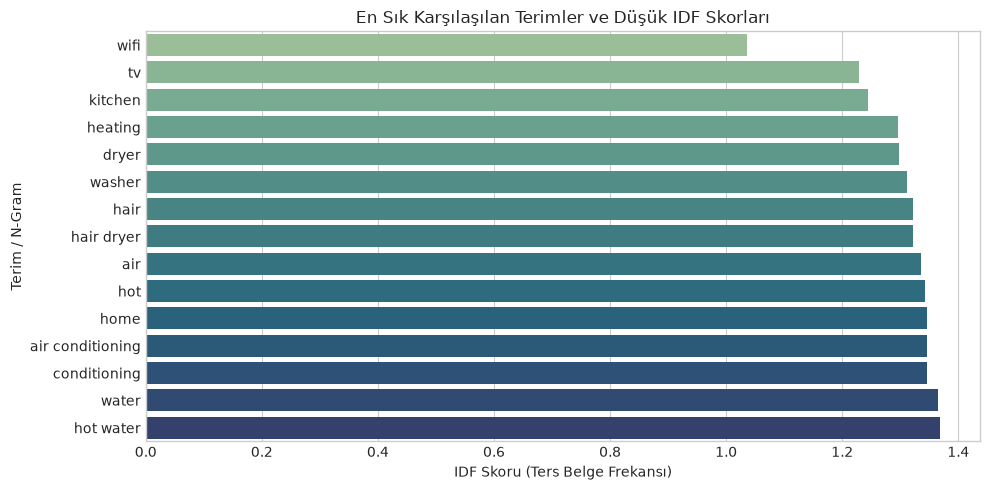

In [6]:
# En sık geçen ilk 15 terimin görselleştirilmesi
plt.figure(figsize=(10, 5))
top15_common = df_idf.head(15)
sns.barplot(x='IDF_Skoru', y='Terim', data=top15_common, palette='crest')
plt.title('En Sık Karşılaşılan Terimler ve Düşük IDF Skorları', fontsize=12)
plt.xlabel('IDF Skoru (Ters Belge Frekansı)', fontsize=10)
plt.ylabel('Terim / N-Gram', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Vektörleştiricinin Serileştirilmesi (Serialization)

Eğitilen `TfidfVectorizer` nesnesi, FastAPI ML mikroservisinde (`ml_service`) ve Cosine Similarity benzerlik hesaplamalarında kullanılmak üzere disk üzerine kaydedilmektedir.


In [7]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

vectorizer_save_path = os.path.join(models_dir, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, vectorizer_save_path)

file_size_kb = os.path.getsize(vectorizer_save_path) / 1024
print(f"Vektörleştirici Başarıyla Serileştirildi:")
print(f"Dosya Konumu: {vectorizer_save_path}")
print(f"Dosya Boyutu: {file_size_kb:,.2f} KB")

Vektörleştirici Başarıyla Serileştirildi:
Dosya Konumu: ..\models\tfidf_vectorizer.joblib
Dosya Boyutu: 201.16 KB


## 6. Yönetici Özeti ve Analitik Bulgular

1. **Metin Madenciliği Hattı:** `name`, `description`, `neighbourhood_cleansed`, `room_type` ve `amenities` değişkenleri temizlenerek 22.665 ilan için kapsamlı bir metin korpusu (`combined_features`) üretilmiştir.
2. **TF-IDF Vektör Uzayı:** 5.000 özniteliklik (unigram & bigram) bir kelime dağarcığı oluşturulmuş ve $(22.665 \times 5.000)$ boyutunda, **%97.08 seyrekliğe (sparsity)** sahip optimize edilmiş bir seyrek matris (CSR matrix) elde edilmiştir.
3. **Model Dışa Aktarımı:** Vektörleştirici `data_science/models/tfidf_vectorizer.joblib` olarak dışa aktarılmış olup Gün 7'deki Cosine Similarity (Kosinüs Benzerliği) hesaplamalarına hazır hale getirilmiştir.
